# 07b — Validación Externa con SWaT A6 (Diciembre 2019)

**Objetivo:** evaluar los tres modelos Conv1D autoencoder (real_only, synthetic_only,
real_plus_synthetic) sobre el dataset SWaT A6 de diciembre 2019, que contiene ataques etiquetados.

## Correcciones respecto a la versión anterior

| # | Error | Corrección |
|---|-------|------------|
| 1 | SCENARIOS/WINDOW/STRIDE leídos de `columns_config.json` | Leídos de `config.json` (igual que A12) |
| 2 | `scaler.pkl` (no existe) | `scaler_cont.pkl` |
| 3 | `disc_max.json` con `json.load` | `disc_max.pkl` con `joblib.load` |
| 4 | `tau.json` | `tau_dict.json` |
| 5 | `dict.get()` col por col para disc_max | `pd.Series.reindex()` (igual que A12) |
| 6 | Arquitectura distinta (3×Conv1d sin MaxPool) | Arquitectura correcta con MaxPool |
| 7 | `glob(*.pt)` riesgoso + `seq_len` no existe | `model_state.pt` explícito |
| 8 | Loop manual para errores | `DataLoader + TensorDataset` |

## Contexto del dataset A6

SWaT A6 (Diciembre 2019) contiene 5 ciclos de ~3 minutos del Segundo ataque
(Disrupt Sensor and Actuator). El Primer ataque (Historian Exfiltration) es de
red y no se refleja en los sensores del CSV.


## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import joblib
import warnings
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 40)


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir = Path.cwd()
if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "data").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir.parent

A6_CSV_PATH          = PROJECT_ROOT / "data" / "clean" / "SWaT.A6_OTDataset_Dec_19" / "Dec2019_labeled.csv"
INTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_internal_validation"
MODELS_DIR           = PROJECT_ROOT / "models" / "detectors" / "conv1d_tstr_internal"
EXTERNAL_RESULTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_external_validation_A6"
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("A6_CSV_PATH  exists:", A6_CSV_PATH.exists())
print("INTERNAL_ARTIFACTS_DIR exists:", INTERNAL_ARTIFACTS_DIR.exists())
print("MODELS_DIR   exists:", MODELS_DIR.exists())


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
A6_CSV_PATH  exists: True
INTERNAL_ARTIFACTS_DIR exists: True
MODELS_DIR   exists: True


In [4]:
# FIX #1/#2/#3/#4: rutas exactas de artefactos (iguales que A12)
required_paths = [
    A6_CSV_PATH,
    INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl",    # FIX: era scaler.pkl
    INTERNAL_ARTIFACTS_DIR / "disc_max.pkl",       # FIX: era disc_max.json
    INTERNAL_ARTIFACTS_DIR / "columns_config.json",
    INTERNAL_ARTIFACTS_DIR / "config.json",        # FIX: nuevo archivo requerido
    MODELS_DIR / "real_only",
    MODELS_DIR / "synthetic_only",
    MODELS_DIR / "real_plus_synthetic",
]
all_ok = True
for p in required_paths:
    exists = p.exists()
    print(f"  {'✅' if exists else '❌'} {p.name}")
    if not exists:
        all_ok = False
if all_ok:
    print("\n✅ Todos los artefactos encontrados.")
else:
    print("\n❌ Faltan artefactos — revisar rutas.")


  ✅ Dec2019_labeled.csv
  ✅ scaler_cont.pkl
  ✅ disc_max.pkl
  ✅ columns_config.json
  ✅ config.json
  ✅ real_only
  ✅ synthetic_only
  ✅ real_plus_synthetic

✅ Todos los artefactos encontrados.


## 2. Cargar artefactos del pipeline interno (A7 2020)

Se cargan exactamente los mismos artefactos que usa el notebook A12.

In [5]:
# FIX #1: SCENARIOS/WINDOW/STRIDE vienen de config.json, no de columns_config.json
with open(INTERNAL_ARTIFACTS_DIR / "columns_config.json") as f:
    columns_config = json.load(f)
with open(INTERNAL_ARTIFACTS_DIR / "config.json") as f:
    internal_config = json.load(f)

continuous_cols = columns_config["continuous_cols"]
discrete_cols   = columns_config["discrete_cols"]
feature_cols    = columns_config["feature_cols"]
WINDOW_SIZE     = int(internal_config["window_size"])
STRIDE          = int(internal_config["stride"])
SCENARIOS       = internal_config["scenarios"]

print(f"Scenarios: {SCENARIOS}")
print(f"Window size: {WINDOW_SIZE} | Stride: {STRIDE}")
print(f"Continuous cols: {len(continuous_cols)}")
print(f"Discrete cols:   {len(discrete_cols)}")
print(f"Total features:  {len(feature_cols)}")


Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
Window size: 60 | Stride: 5
Continuous cols: 23
Discrete cols:   26
Total features:  49


In [6]:
# FIX #2/#3: scaler_cont.pkl y disc_max.pkl con joblib (igual que A12)
scaler_cont = joblib.load(INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl")
disc_max    = joblib.load(INTERNAL_ARTIFACTS_DIR / "disc_max.pkl")

# FIX #4: tau_dict.json (no tau.json)
tau_dicts = {}
for scenario in SCENARIOS:
    tau_path = MODELS_DIR / scenario / "tau_dict.json"
    if not tau_path.exists():
        raise FileNotFoundError(f"tau_dict.json no encontrado: {tau_path}")
    with open(tau_path) as f:
        tau_dicts[scenario] = json.load(f)

print("Tau dicts cargados:")
for scenario, taus in tau_dicts.items():
    print(f"  {scenario}: p95={float(taus.get('p95', float('nan'))):.4f}  "
          f"p99={float(taus.get('p99', float('nan'))):.4f}")


Tau dicts cargados:
  real_only: p95=0.4527  p99=0.5796
  synthetic_only: p95=0.5871  p99=1.7256
  real_plus_synthetic: p95=0.3009  p99=0.3278


## 3. Cargar dataset A6 y aplicar etiquetas del log

Solo el Segundo ataque (Disrupt Sensor and Actuator) es visible en los datos del proceso.
El Primero (Historian Exfiltration) es de red.

In [7]:
a6_df = pd.read_csv(A6_CSV_PATH, low_memory=False)
a6_df["t_stamp"] = pd.to_datetime(a6_df["t_stamp"], errors="coerce")
a6_df = a6_df.dropna(subset=["t_stamp"]).reset_index(drop=True)

print(f"A6 shape: {a6_df.shape}")
print(f"Período: {a6_df['t_stamp'].min()} → {a6_df['t_stamp'].max()}")

diffs = a6_df["t_stamp"].diff().dropna()
print(f"Intervalo más común: {diffs.mode().iloc[0]}")


A6 shape: (13201, 87)
Período: 2019-12-06 10:05:00 → 2019-12-06 13:45:00
Intervalo más común: 0 days 00:00:01


In [8]:
DATE = a6_df["t_stamp"].dt.date.mode()[0]
print(f"Fecha detectada: {DATE}")

# 5 ciclos de ataque (intervalo semiabierto: start <= t_stamp < end)
ATTACK_WINDOWS = [
    ("12:30:00", "12:33:00"),   # Ciclo 1
    ("12:43:00", "12:46:00"),   # Ciclo 2
    ("12:56:00", "12:59:00"),   # Ciclo 3
    ("13:09:00", "13:12:00"),   # Ciclo 4
    ("13:22:00", "13:25:00"),   # Ciclo 5
]

a6_df["attack_label"] = 0
total_attack_rows = 0
for start_str, end_str in ATTACK_WINDOWS:
    t_start = pd.Timestamp(f"{DATE} {start_str}")
    t_end   = pd.Timestamp(f"{DATE} {end_str}")
    mask = (a6_df["t_stamp"] >= t_start) & (a6_df["t_stamp"] < t_end)
    a6_df.loc[mask, "attack_label"] = 1
    n = mask.sum()
    total_attack_rows += n
    print(f"  {start_str}–{end_str}: {n:4d} filas de ataque")

print(f"\nTotal ataque: {total_attack_rows} ({100*total_attack_rows/len(a6_df):.1f}%)")
print(f"Total normal:  {(a6_df['attack_label']==0).sum()} ({100*(a6_df['attack_label']==0).sum()/len(a6_df):.1f}%)")


Fecha detectada: 2019-12-06
  12:30:00–12:33:00:  180 filas de ataque
  12:43:00–12:46:00:  180 filas de ataque
  12:56:00–12:59:00:  180 filas de ataque
  13:09:00–13:12:00:  180 filas de ataque
  13:22:00–13:25:00:  180 filas de ataque

Total ataque: 900 (6.8%)
Total normal:  12301 (93.2%)


## 4. Verificar columnas y eliminar nulos

In [9]:
missing_cont = [c for c in continuous_cols if c not in a6_df.columns]
missing_disc = [c for c in discrete_cols   if c not in a6_df.columns]

if missing_cont:
    print(f"❌ Continuas faltantes ({len(missing_cont)}): {missing_cont}")
else:
    print(f"✅ Todas las {len(continuous_cols)} columnas continuas presentes")

if missing_disc:
    print(f"❌ Discretas faltantes ({len(missing_disc)}): {missing_disc}")
else:
    print(f"✅ Todas las {len(discrete_cols)} columnas discretas presentes")

a6_work = a6_df[["t_stamp", "attack_label"] + feature_cols].copy()
for col in feature_cols:
    a6_work[col] = pd.to_numeric(a6_work[col], errors="coerce")

missing_by_col = a6_work[feature_cols].isna().sum()
if missing_by_col.sum() > 0:
    print("\nNaN por columna (top):")
    display(missing_by_col[missing_by_col > 0].sort_values(ascending=False).head(10))

before = len(a6_work)
a6_work = a6_work.dropna(subset=feature_cols).reset_index(drop=True)
print(f"\nFilas: {before} → {len(a6_work)} (eliminadas: {before-len(a6_work)})")


✅ Todas las 23 columnas continuas presentes
✅ Todas las 26 columnas discretas presentes

NaN por columna (top):


P101.Status    1
dtype: int64


Filas: 13201 → 13200 (eliminadas: 1)


## 5. Preprocesamiento con el scaler de A7

Se aplica exactamente el mismo pipeline que en el notebook de entrenamiento interno y A12.

In [10]:
# Continuas — StandardScaler de A7
a6_cont_scaled = pd.DataFrame(
    scaler_cont.transform(a6_work[continuous_cols]),
    columns=continuous_cols,
    index=a6_work.index
)

# FIX #5: discretas con pd.Series.reindex (igual que A12)
disc_max_aligned = pd.Series(disc_max).reindex(discrete_cols)
if disc_max_aligned.isna().any():
    raise ValueError("disc_max no contiene todas las columnas discretas requeridas.")
disc_max_aligned = disc_max_aligned.replace(0, 1)

a6_disc_scaled = a6_work[discrete_cols].copy() / disc_max_aligned

# Concatenar en el orden exacto de feature_cols
a6_scaled = pd.concat(
    [a6_cont_scaled.reset_index(drop=True), a6_disc_scaled.reset_index(drop=True)],
    axis=1
)[feature_cols]

print(f"A6 escalado shape: {a6_scaled.shape}")
print(f"Rango continuas: [{a6_scaled[continuous_cols].values.min():.2f}, "
      f"{a6_scaled[continuous_cols].values.max():.2f}]")
print("(Esperado ≈ [-4, 4] si A6 y A7 son compatibles)")
display(a6_scaled.head(3))


A6 escalado shape: (13200, 49)
Rango continuas: [-2.61, 25.76]
(Esperado ≈ [-4, 4] si A6 y A7 son compatibles)


,AIT201.Pv,AIT202.Pv,AIT203.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,DPIT301.Pv,FIT101.Pv,FIT201.Pv,FIT301.Pv,FIT401.Pv,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,FIT601.Pv,LIT101.Pv,LIT301.Pv,LIT401.Pv,...,MV501.Status,MV502.Status,MV503.Status,MV504.Status,P101.Status,P201.Status,P203.Status,P205.Status,P301.Status,P401.Status,P501.Status,P601.Status,P602.Status,UV401.Status,P1_STATE,P2_STATE,P3_STATE,P4_STATE,P5_STATE,P6_STATE
0,-0.264639,0.158082,-0.375093,-2.558430,0.036281,-1.403742,-0.353393,0.985540,-0.310613,1.323779,1.132000,1.087413,1.076503,1.094718,1.002093,-0.007226,-0.043717,-0.488166,0.437173,0.066038,...,1.000000,1.000000,0.500000,0.500000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,0.070707,1.000000,0.571429,1.000000
1,-0.264639,0.158082,-0.373280,-2.533439,0.036281,-1.403742,-0.353393,0.985540,-0.310613,1.322287,1.129611,1.087413,1.076503,1.095589,1.006642,-0.007226,-0.043717,-0.482787,0.437173,0.064771,...,1.000000,1.000000,0.500000,0.500000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,0.070707,1.000000,0.571429,1.000000
2,-0.264639,0.160637,-0.366029,-2.502200,0.036281,-1.403742,-0.353393,0.985540,-0.310613,1.322058,1.129611,1.087413,1.076503,1.083391,1.006642,-0.007226,-0.043717,-0.477411,0.437173,0.065615,...,1.000000,1.000000,0.500000,0.500000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,0.070707,1.000000,0.571429,1.000000


## 6. Diagnóstico de domain shift A7 → A6

**Interpretación:** |media| < 1 → compatible ✅ | 1–5 → drift moderado ⚠️ | > 5 → drift severo ❌

In [11]:
cont_arr = a6_scaled[continuous_cols].values

drift_df = pd.DataFrame({
    "feature":     continuous_cols,
    "mean_scaled": cont_arr.mean(axis=0),
    "std_scaled":  cont_arr.std(axis=0),
    "min_scaled":  cont_arr.min(axis=0),
    "max_scaled":  cont_arr.max(axis=0),
}).assign(mean_drift_abs=lambda d: d["mean_scaled"].abs()).sort_values("mean_drift_abs", ascending=False)

print("="*65)
print("DIAGNÓSTICO DE DOMAIN SHIFT A7 (train) → A6 (test externo)")
print("="*65)
print("StandardScaler entrenado en A7 2020. Aplicado a A6 Dic 2019.")
print("Valores esperados (misma distribución): media≈0, std≈1")
print()
print("Top 10 features con mayor desplazamiento:")
print(drift_df[["feature","mean_scaled","std_scaled","min_scaled","max_scaled"]].head(10).to_string(index=False))

moderate = (drift_df["mean_drift_abs"] > 1).sum()
severe   = (drift_df["mean_drift_abs"] > 5).sum()
print(f"\nFeatures con |media| > 1σ: {moderate}/{len(continuous_cols)}")
print(f"Features con |media| > 5σ: {severe}/{len(continuous_cols)}")
print(f"Rango global continuas A6: [{cont_arr.min():.2f}, {cont_arr.max():.2f}]")

disc_arr = a6_scaled[discrete_cols].values
disc_out = (disc_arr > 1.01).sum()
print(f"Valores discretos > 1.0: {disc_out} ({100*disc_out/disc_arr.size:.2f}%)")


DIAGNÓSTICO DE DOMAIN SHIFT A7 (train) → A6 (test externo)
StandardScaler entrenado en A7 2020. Aplicado a A6 Dic 2019.
Valores esperados (misma distribución): media≈0, std≈1

Top 10 features con mayor desplazamiento:
  feature  mean_scaled  std_scaled  min_scaled  max_scaled
AIT501.Pv    -2.048958    0.172414   -2.608413   -1.644170
FIT502.Pv     1.113450    0.024599    1.027193    1.207332
FIT401.Pv     1.096205    0.005396    1.076347    1.113426
FIT501.Pv     1.094984    0.007159    1.059292    1.114212
FIT503.Pv     0.993354    0.016999    0.922487    1.040759
PIT501.Pv     0.956418    0.006830    0.939036    0.967619
PIT503.Pv     0.932474    0.007122    0.914541    0.945114
FIT301.Pv     0.727070    0.760616   -0.784278    1.333916
FIT201.Pv     0.555275    1.005883   -0.747307    1.358654
LIT301.Pv     0.470696    0.368205   -0.113085    1.056134

Features con |media| > 1σ: 4/23
Features con |media| > 5σ: 0/23
Rango global continuas A6: [-2.61, 25.76]
Valores discretos > 1.0: 0

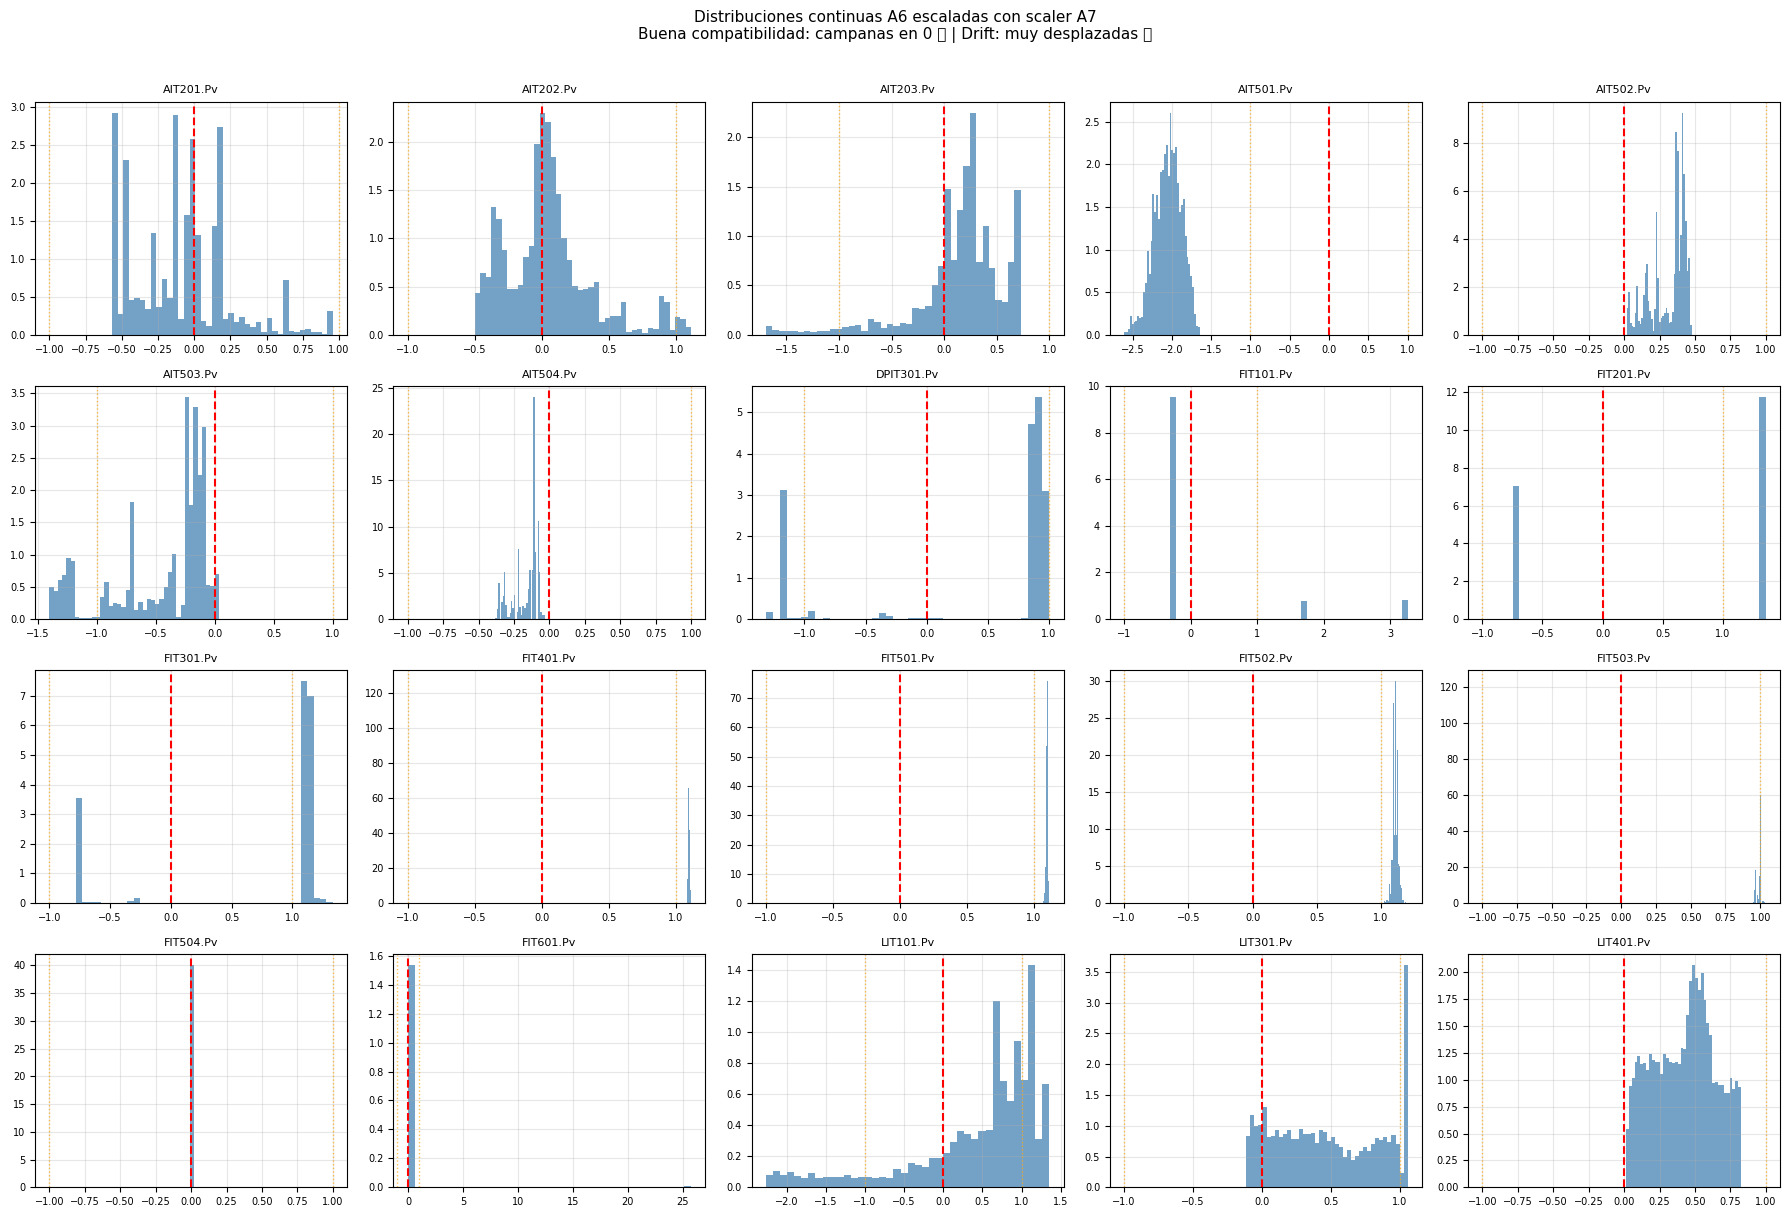

✅ Guardado: domain_shift_A6_distributions.png


In [12]:
n_plot = min(len(continuous_cols), 20)
ncols = 5
nrows = (n_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
axes = axes.flatten()

for j, col in enumerate(continuous_cols[:n_plot]):
    axes[j].hist(a6_scaled[col].dropna(), bins=40, color="steelblue", alpha=0.75, density=True)
    axes[j].axvline(0,  color="red",    linestyle="--", linewidth=1.5)
    axes[j].axvline(-1, color="orange", linestyle=":",  linewidth=1,  alpha=0.7)
    axes[j].axvline( 1, color="orange", linestyle=":",  linewidth=1,  alpha=0.7)
    axes[j].set_title(col, fontsize=8)
    axes[j].grid(True, alpha=0.3)
    axes[j].tick_params(labelsize=7)

for j in range(n_plot, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribuciones continuas A6 escaladas con scaler A7\n"
             "Buena compatibilidad: campanas en 0 ✅ | Drift: muy desplazadas ❌",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "domain_shift_A6_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Guardado: domain_shift_A6_distributions.png")


## 7. Construcción de ventanas etiquetadas

Idéntica al notebook A12. Estrategia `any`: si algún timestep de la ventana pertenece a un ataque, la ventana es positiva.

In [13]:
def build_labeled_windows(scaled_df, labels, timestamps,
                         window_size=60, stride=5,
                         label_strategy="any", min_attack_ratio=0.1):
    """Idéntica al notebook A12 para garantizar comparabilidad."""
    windows, window_labels, attack_ratios = [], [], []
    start_times, end_times = [], []

    values     = scaled_df.values.astype(np.float32)
    labels_arr = np.asarray(labels).astype(int)
    times_arr  = np.asarray(timestamps)

    for start in range(0, len(values) - window_size + 1, stride):
        end   = start + window_size
        y_w   = labels_arr[start:end]
        ratio = float(np.mean(y_w))

        if label_strategy == "any":
            y_label = int(ratio > 0)
        elif label_strategy == "ratio":
            y_label = int(ratio >= min_attack_ratio)
        else:
            raise ValueError(f"Unknown label_strategy: {label_strategy}")

        windows.append(values[start:end])
        window_labels.append(y_label)
        attack_ratios.append(ratio)
        start_times.append(str(times_arr[start]))
        end_times.append(str(times_arr[end - 1]))

    X = np.array(windows, dtype=np.float32)
    y = np.array(window_labels, dtype=int)
    metadata = pd.DataFrame({
        "window_start": start_times,
        "window_end":   end_times,
        "label_any":    y,
        "attack_ratio": attack_ratios,
    })
    return X, y, metadata


X_a6_seq, y_a6, window_meta = build_labeled_windows(
    scaled_df=a6_scaled[feature_cols],
    labels=a6_work["attack_label"].values,
    timestamps=a6_work["t_stamp"].values,
    window_size=WINDOW_SIZE, stride=STRIDE, label_strategy="any",
)
# Conv1D espera (N, features, window_size)
X_a6 = np.transpose(X_a6_seq, (0, 2, 1)).astype(np.float32)

print(f"X_a6 shape: {X_a6.shape}   (N, features, timesteps)")
print(f"y_a6 shape: {y_a6.shape}")
label_counts = pd.Series(y_a6).value_counts().rename({0:"normal", 1:"ataque"})
print("\nDistribución de ventanas (estrategia 'any'):")
print(label_counts.to_string())
print(f"\nRatio de ventanas de ataque: {100*y_a6.mean():.1f}%")


X_a6 shape: (2629, 49, 60)   (N, features, timesteps)
y_a6 shape: (2629,)

Distribución de ventanas (estrategia 'any'):
normal    2391
ataque     238

Ratio de ventanas de ataque: 9.1%


In [14]:
# Estrategias alternativas para análisis de sensibilidad
label_strategies = {"any": y_a6.copy()}
for ratio_th in [0.10, 0.20, 0.50]:
    key = f"ratio_{int(ratio_th*100)}"
    _, y_tmp, _ = build_labeled_windows(
        scaled_df=a6_scaled[feature_cols],
        labels=a6_work["attack_label"].values,
        timestamps=a6_work["t_stamp"].values,
        window_size=WINDOW_SIZE, stride=STRIDE,
        label_strategy="ratio", min_attack_ratio=ratio_th,
    )
    label_strategies[key] = y_tmp

label_counts_df = pd.DataFrame([
    {"strategy": k, "normal": int((v==0).sum()),
     "attack": int((v==1).sum()), "attack_ratio": float(v.mean())}
    for k, v in label_strategies.items()
])
display(label_counts_df)


,strategy,normal,attack,attack_ratio
0,any,2391,238,0.090529
1,ratio_10,2401,228,0.086725
2,ratio_20,2414,215,0.081780
3,ratio_50,2447,182,0.069228


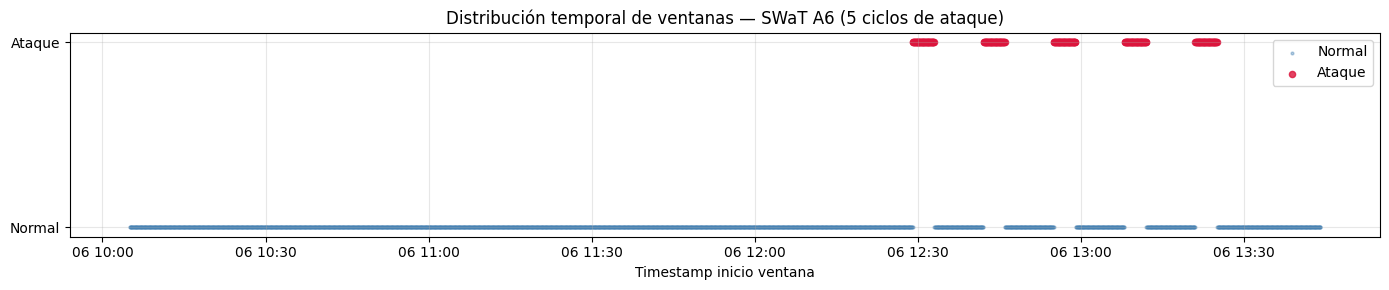

In [15]:
# Visualización temporal
fig, ax = plt.subplots(figsize=(14, 3))
ts_start = pd.to_datetime(window_meta["window_start"])
ax.scatter(ts_start[y_a6==0], np.zeros((y_a6==0).sum()), s=4,  c="steelblue", alpha=0.4, label="Normal")
ax.scatter(ts_start[y_a6==1], np.ones((y_a6==1).sum()),  s=20, c="crimson",   alpha=0.8, label="Ataque")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Ataque"])
ax.set_xlabel("Timestamp inicio ventana")
ax.set_title("Distribución temporal de ventanas — SWaT A6 (5 ciclos de ataque)")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "window_timeline_A6.png"), dpi=120, bbox_inches="tight")
plt.show()


## 8. Arquitectura Conv1D y carga de modelos

**FIX crítico #6:** arquitectura idéntica al entrenamiento interno (Conv→MaxPool×2).

In [16]:
# FIX #6: arquitectura correcta con MaxPool (igual que entrenamiento y A12)
class Conv1dAutoencoder(nn.Module):
    def __init__(self, input_channels):
        super(Conv1dAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=input_channels, kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [17]:
# FIX #7: model_state.pt explícito (igual que A12)
def load_scenario_model(scenario, input_channels, device):
    state_path = MODELS_DIR / scenario / "model_state.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"model_state.pt no encontrado: {state_path}")
    model = Conv1dAutoencoder(input_channels=input_channels).to(device)
    state = torch.load(state_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

input_channels = X_a6.shape[1]   # 49 (23 cont + 26 disc)
models = {}
for scenario in SCENARIOS:
    models[scenario] = load_scenario_model(scenario, input_channels, device)
    print(f"✅ {scenario:25s} — {input_channels} canales")

print(f"\nArquitectura: Conv1D+MaxPool | in_channels={input_channels} | seq_len={WINDOW_SIZE}")


✅ real_only                 — 49 canales
✅ synthetic_only            — 49 canales
✅ real_plus_synthetic       — 49 canales

Arquitectura: Conv1D+MaxPool | in_channels=49 | seq_len=60


## 9. Errores de reconstrucción en A6

In [18]:
# FIX #8: DataLoader + TensorDataset (igual que A12)
def reconstruction_errors(model, X, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    errors = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)
            err = torch.mean((x_hat - x) ** 2, dim=(1, 2))
            errors.extend(err.detach().cpu().numpy())
    return np.array(errors)

external_errors = {}
for scenario, model in models.items():
    external_errors[scenario] = reconstruction_errors(model, X_a6, batch_size=256)

print(f"{'Scenario':<25} {'mean':>10} {'std':>10} {'p95':>10} {'p99':>10}")
print("-"*67)
for sc in SCENARIOS:
    e = external_errors[sc]
    print(f"{sc:<25} {e.mean():>10.4f} {e.std():>10.4f} "
          f"{np.percentile(e,95):>10.4f} {np.percentile(e,99):>10.4f}")


Scenario                        mean        std        p95        p99
-------------------------------------------------------------------
real_only                     0.1560     0.0905     0.3197     0.5636
synthetic_only                0.2841     0.4067     0.3039     3.1580
real_plus_synthetic           0.1378     0.0771     0.1910     0.6392


In [19]:
# Comparar con umbrales internos A7
print("Errores A6 vs umbrales internos A7 (τ p99):")
print(f"{'Scenario':<25} {'mean_A6':>10} {'τ_p99_A7':>10} {'ratio':>8}  Estado")
print("-"*75)
for sc in SCENARIOS:
    e    = external_errors[sc]
    tau  = float(tau_dicts[sc]["p99"])
    ratio = e.mean() / tau
    estado = "✅ Compatible" if ratio < 2 else ("⚠️  Drift moderado" if ratio < 10 else "❌ Drift severo")
    print(f"{sc:<25} {e.mean():>10.4f} {tau:>10.4f} {ratio:>8.2f}x  {estado}")


Errores A6 vs umbrales internos A7 (τ p99):
Scenario                     mean_A6   τ_p99_A7    ratio  Estado
---------------------------------------------------------------------------
real_only                     0.1560     0.5796     0.27x  ✅ Compatible
synthetic_only                0.2841     1.7256     0.16x  ✅ Compatible
real_plus_synthetic           0.1378     0.3278     0.42x  ✅ Compatible


## 10. Funciones de métricas

In [20]:
def safe_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, scores))

def safe_pr_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, scores))

def compute_classification_metrics(y_true, scores, threshold):
    y_pred = (scores > threshold).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    tn = int(((y_pred==0) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    precision  = tp / (tp + fp + 1e-10)
    recall     = tp / (tp + fn + 1e-10)
    f1         = 2*precision*recall / (precision+recall+1e-10)
    specificity = tn / (tn + fp + 1e-10)
    fpr         = fp / (fp + tn + 1e-10)
    bal_acc     = (recall + specificity) / 2
    return {"threshold": float(threshold), "precision": float(precision),
            "recall": float(recall), "f1": float(f1),
            "balanced_accuracy": float(bal_acc), "specificity": float(specificity),
            "fpr": float(fpr), "tp": tp, "fp": fp, "tn": tn, "fn": fn}

PRIMARY_TAU = "p99"
y_primary   = label_strategies["any"]


## 11. Métricas con umbrales internos de A7

In [21]:
rows_a7 = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    base = {"scenario": sc, "tau_source": "A7_internal",
            "roc_auc": safe_auc(y_primary, scores),
            "pr_auc":  safe_pr_auc(y_primary, scores),
            "score_mean": float(scores.mean()), "score_p99": float(np.percentile(scores,99))}
    for tau_name, tau_val in tau_dicts[sc].items():
        m = compute_classification_metrics(y_primary, scores, float(tau_val))
        rows_a7.append({**base, "tau_name": tau_name, **m})

metrics_a7_df = pd.DataFrame(rows_a7)
main_a7_df    = metrics_a7_df[metrics_a7_df["tau_name"] == PRIMARY_TAU].copy()
print(f"Métricas con umbrales A7 (τ={PRIMARY_TAU}):")
display(main_a7_df[["scenario","tau_source","roc_auc","pr_auc",
                     "precision","recall","f1","balanced_accuracy","specificity","fpr","tp","fp","tn","fn"]])


Métricas con umbrales A7 (τ=p99):


,scenario,tau_source,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,specificity,fpr,tp,fp,tn,fn
3,real_only,A7_internal,0.733718,0.222807,0.320000,0.033613,0.060837,0.513252,0.992890,0.007110,8,17,2374,230
8,synthetic_only,A7_internal,0.387187,0.095560,0.333333,0.054622,0.093863,0.521874,0.989126,0.010874,13,26,2365,225
13,real_plus_synthetic,A7_internal,0.523093,0.103532,0.325581,0.058824,0.099644,0.523347,0.987871,0.012129,14,29,2362,224


## 12. Re-calibración de umbrales con datos normales de A6

Datos normales antes del primer ataque (12:30). Es la práctica estándar cuando hay domain shift.

In [22]:
first_attack_time = pd.Timestamp(f"{DATE} 12:30:00")
mask_pre = a6_work["t_stamp"] < first_attack_time
print(f"Primer ataque A6: {first_attack_time}")
print(f"Filas normales pre-ataque: {mask_pre.sum()}")

a6_calib_scaled = a6_scaled[mask_pre.values].reset_index(drop=True)
calib_vals = a6_calib_scaled[feature_cols].values.astype(np.float32)
X_calib_seq = [calib_vals[s:s+WINDOW_SIZE]
               for s in range(0, len(calib_vals)-WINDOW_SIZE+1, STRIDE)]
X_calib = np.transpose(np.array(X_calib_seq, dtype=np.float32), (0, 2, 1))
print(f"Ventanas de calibración normales: {len(X_calib)}")

tau_dicts_a6 = {}
calib_errors  = {}
print(f"\n{'Scenario':<25} {'mean':>10} {'std':>10} {'τ_p95':>10} {'τ_p99':>10}")
print("-"*67)
for sc, model in models.items():
    c_err = reconstruction_errors(model, X_calib, batch_size=256)
    calib_errors[sc] = c_err
    tau_a6 = {"p90":   float(np.percentile(c_err, 90)),
               "p95":   float(np.percentile(c_err, 95)),
               "p97_5": float(np.percentile(c_err, 97.5)),
               "p99":   float(np.percentile(c_err, 99)),
               "p99_5": float(np.percentile(c_err, 99.5))}
    tau_dicts_a6[sc] = tau_a6
    print(f"{sc:<25} {c_err.mean():>10.4f} {c_err.std():>10.4f} "
          f"{tau_a6['p95']:>10.4f} {tau_a6['p99']:>10.4f}")


Primer ataque A6: 2019-12-06 12:30:00
Filas normales pre-ataque: 8700
Ventanas de calibración normales: 1729

Scenario                        mean        std      τ_p95      τ_p99
-------------------------------------------------------------------
real_only                     0.1614     0.0899     0.3697     0.5636
synthetic_only                0.2954     0.4060     0.3101     3.1929
real_plus_synthetic           0.1472     0.0793     0.1954     0.6433


In [23]:
rows_a6calib = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    base = {"scenario": sc, "tau_source": "A6_recalibrated",
            "roc_auc": safe_auc(y_primary, scores),
            "pr_auc":  safe_pr_auc(y_primary, scores),
            "score_mean": float(scores.mean())}
    for tau_name, tau_val in tau_dicts_a6[sc].items():
        m = compute_classification_metrics(y_primary, scores, float(tau_val))
        rows_a6calib.append({**base, "tau_name": tau_name, **m})

metrics_a6calib_df = pd.DataFrame(rows_a6calib)
main_a6calib_df    = metrics_a6calib_df[metrics_a6calib_df["tau_name"] == PRIMARY_TAU].copy()
print(f"Métricas con umbrales re-calibrados A6 (τ={PRIMARY_TAU}):")
display(main_a6calib_df[["scenario","tau_source","roc_auc","pr_auc",
                          "precision","recall","f1","balanced_accuracy","specificity","fpr","tp","fp","tn","fn"]])

print(f"\nComparativa umbrales A7 vs re-calibrados A6 ({PRIMARY_TAU}):")
comp = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    sc_a7  = main_a7_df[main_a7_df["scenario"]==sc].iloc[0]
    sc_a6c = main_a6calib_df[main_a6calib_df["scenario"]==sc].iloc[0]
    comp.append({"scenario": sc,
                 "τ_A7": round(float(tau_dicts[sc][PRIMARY_TAU]),4),
                 "f1_A7": round(float(sc_a7["f1"]),4),
                 "recall_A7": round(float(sc_a7["recall"]),4),
                 "FPR_A7": round(float(sc_a7["fpr"]),4),
                 "τ_A6calib": round(float(tau_dicts_a6[sc][PRIMARY_TAU]),4),
                 "f1_A6calib": round(float(sc_a6c["f1"]),4),
                 "recall_A6": round(float(sc_a6c["recall"]),4),
                 "FPR_A6": round(float(sc_a6c["fpr"]),4)})
print(pd.DataFrame(comp).to_string(index=False))


Métricas con umbrales re-calibrados A6 (τ=p99):


,scenario,tau_source,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,specificity,fpr,tp,fp,tn,fn
3,real_only,A6_recalibrated,0.733718,0.222807,0.333333,0.037815,0.067925,0.515143,0.992472,0.007528,9,18,2373,229
8,synthetic_only,A6_recalibrated,0.387187,0.095560,0.333333,0.037815,0.067925,0.515143,0.992472,0.007528,9,18,2373,229
13,real_plus_synthetic,A6_recalibrated,0.523093,0.103532,0.307692,0.033613,0.060606,0.513043,0.992472,0.007528,8,18,2373,230



Comparativa umbrales A7 vs re-calibrados A6 (p99):
           scenario     τ_A7    f1_A7  recall_A7   FPR_A7  τ_A6calib  f1_A6calib  recall_A6   FPR_A6
          real_only 0.579600 0.060800   0.033600 0.007100   0.563600    0.067900   0.037800 0.007500
     synthetic_only 1.725600 0.093900   0.054600 0.010900   3.192900    0.067900   0.037800 0.007500
real_plus_synthetic 0.327800 0.099600   0.058800 0.012100   0.643300    0.060600   0.033600 0.007500


## 13. Curvas ROC, PR y distribuciones de error

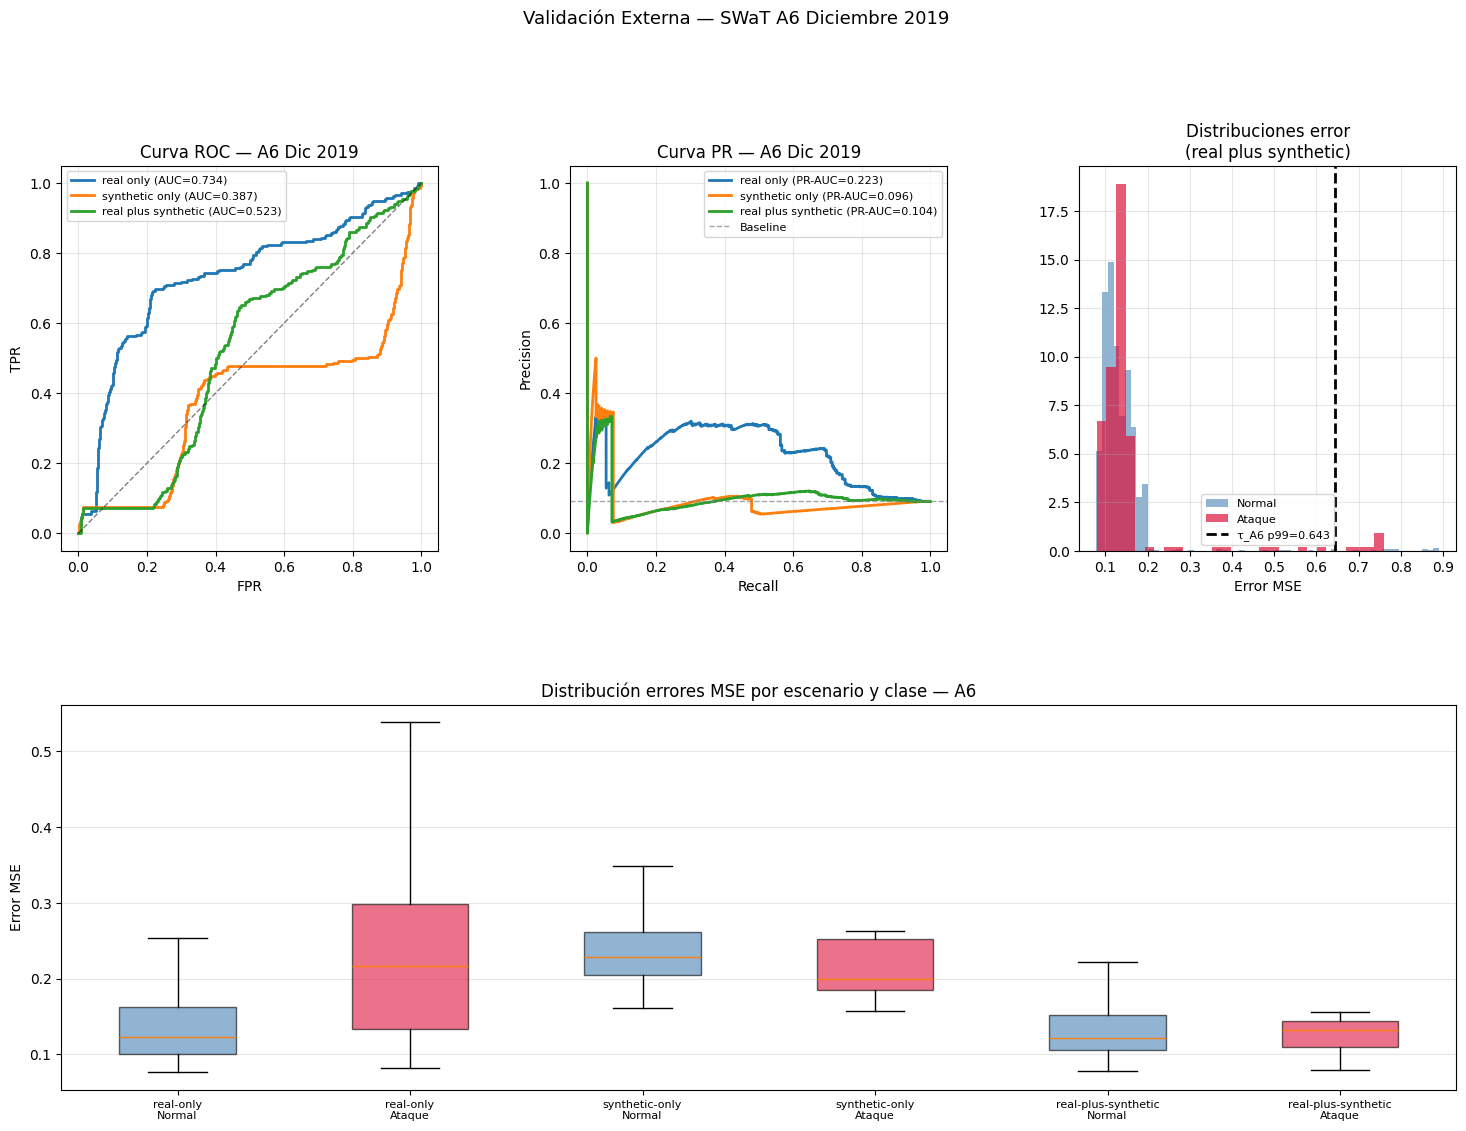

✅ Guardado: external_metrics_A6_curves.png


In [24]:
COLORS = {"real_only":"#1f77b4", "synthetic_only":"#ff7f0e", "real_plus_synthetic":"#2ca02c"}

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ROC
ax_roc = fig.add_subplot(gs[0, 0])
for sc, scores in external_errors.items():
    fpr_c, tpr_c, _ = roc_curve(y_primary, scores)
    ax_roc.plot(fpr_c, tpr_c, color=COLORS[sc], lw=2,
                label=f"{sc.replace('_',' ')} (AUC={safe_auc(y_primary,scores):.3f})")
ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("Curva ROC — A6 Dic 2019")
ax_roc.legend(fontsize=8); ax_roc.grid(True, alpha=0.3)

# PR
ax_pr = fig.add_subplot(gs[0, 1])
for sc, scores in external_errors.items():
    prec_c, rec_c, _ = precision_recall_curve(y_primary, scores)
    ax_pr.plot(rec_c, prec_c, color=COLORS[sc], lw=2,
               label=f"{sc.replace('_',' ')} (PR-AUC={safe_pr_auc(y_primary,scores):.3f})")
ax_pr.axhline(float(y_primary.mean()), color="gray", linestyle="--", lw=1, alpha=0.7, label="Baseline")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Curva PR — A6 Dic 2019")
ax_pr.legend(fontsize=8); ax_pr.grid(True, alpha=0.3)

# Distribución errores
ax_err = fig.add_subplot(gs[0, 2])
sc_ref = "real_plus_synthetic"
sc_errors = external_errors[sc_ref]
ax_err.hist(sc_errors[y_primary==0], bins=60, alpha=0.6, color="steelblue", density=True, label="Normal")
ax_err.hist(sc_errors[y_primary==1], bins=30, alpha=0.7, color="crimson",   density=True, label="Ataque")
tau_ref = float(tau_dicts_a6[sc_ref][PRIMARY_TAU])
ax_err.axvline(tau_ref, color="black", linestyle="--", lw=2, label=f"τ_A6 {PRIMARY_TAU}={tau_ref:.3f}")
ax_err.set_xlabel("Error MSE"); ax_err.set_title(f"Distribuciones error\n({sc_ref.replace('_',' ')})")
ax_err.legend(fontsize=8); ax_err.grid(True, alpha=0.3)

# Boxplots
ax_box = fig.add_subplot(gs[1, :])
data_box, labels_box, colors_box = [], [], []
for sc in SCENARIOS:
    e = external_errors[sc]
    data_box.extend([e[y_primary==0], e[y_primary==1]])
    labels_box.extend([f"{sc.replace('_','-')}\nNormal", f"{sc.replace('_','-')}\nAtaque"])
    colors_box.extend(["steelblue", "crimson"])
bp = ax_box.boxplot(data_box, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax_box.set_xticklabels(labels_box, fontsize=8)
ax_box.set_ylabel("Error MSE"); ax_box.grid(True, axis="y", alpha=0.3)
ax_box.set_title("Distribución errores MSE por escenario y clase — A6")

plt.suptitle("Validación Externa — SWaT A6 Diciembre 2019", fontsize=13, y=1.01)
plt.savefig(str(EXTERNAL_RESULTS_DIR / "external_metrics_A6_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Guardado: external_metrics_A6_curves.png")


## 14. Comparativa de métricas por escenario

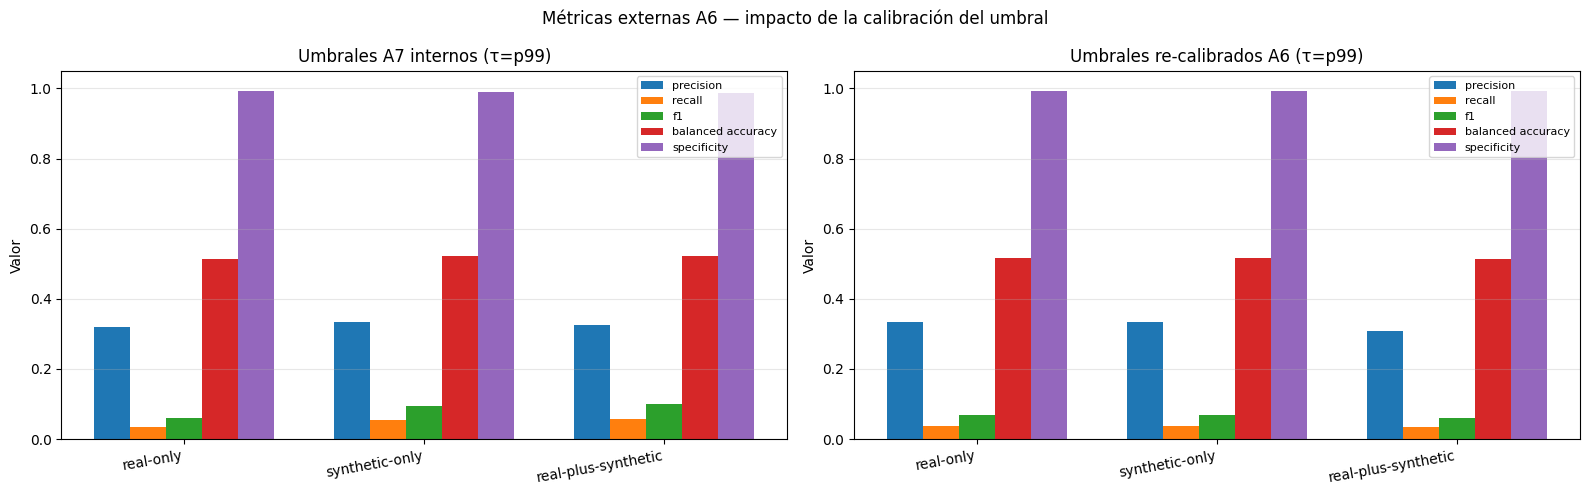

In [25]:
metric_cols = ["precision","recall","f1","balanced_accuracy","specificity"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_plot, title in zip(
    axes,
    [main_a7_df, main_a6calib_df],
    [f"Umbrales A7 internos (τ={PRIMARY_TAU})", f"Umbrales re-calibrados A6 (τ={PRIMARY_TAU})"]
):
    data_plot = df_plot.set_index("scenario")[metric_cols]
    x = np.arange(len(data_plot)); width = 0.15
    for j, col in enumerate(metric_cols):
        ax.bar(x + j*width, data_plot[col].values, width, label=col.replace("_"," "))
    ax.set_xticks(x + width*2)
    ax.set_xticklabels([s.replace("_","-") for s in data_plot.index], rotation=10, ha="right")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Valor"); ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True, axis="y", alpha=0.3)
plt.suptitle("Métricas externas A6 — impacto de la calibración del umbral", fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "metrics_comparison_A6.png"), dpi=120, bbox_inches="tight")
plt.show()


## 15. Análisis por ciclo de ataque

Recall por ciclo (τ=p99, re-calibrado):


scenario,real_only,real_plus_synthetic,synthetic_only
attack_cycle,,,
ciclo_1,0.000000,0.000000,0.000000
ciclo_2,0.320000,0.280000,0.280000
ciclo_3,0.000000,0.000000,0.000000
ciclo_4,0.000000,0.000000,0.000000
ciclo_5,0.000000,0.000000,0.000000


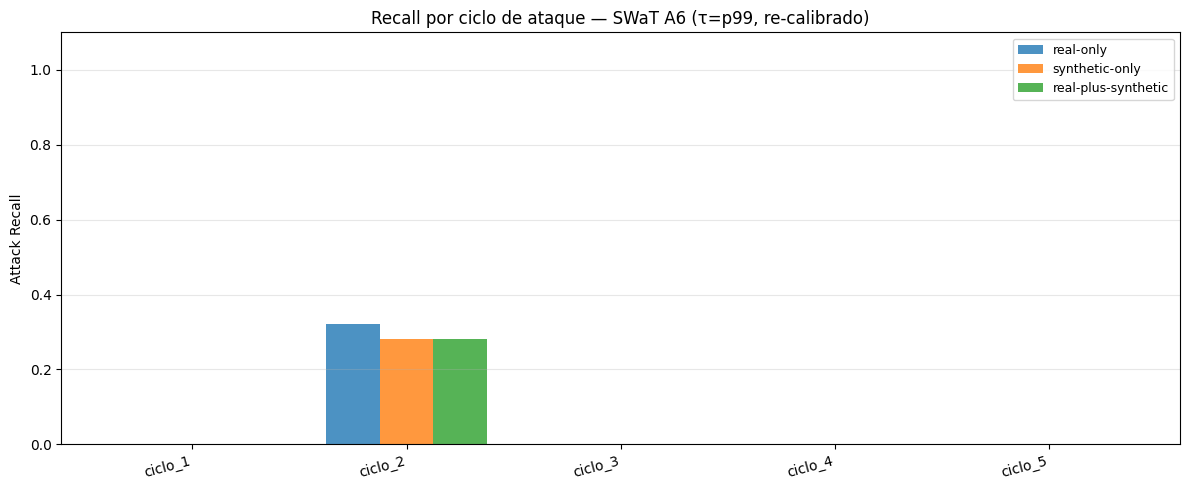

In [26]:
ATTACK_CYCLES = {
    f"ciclo_{i+1}": (f"{DATE} {s}", f"{DATE} {e}")
    for i, (s, e) in enumerate(ATTACK_WINDOWS)
}
window_meta["attack_cycle"] = "normal"
for cycle_name, (t_start_str, t_end_str) in ATTACK_CYCLES.items():
    t_start = pd.Timestamp(t_start_str)
    t_end   = pd.Timestamp(t_end_str)
    mask = ((pd.to_datetime(window_meta["window_start"]) >= t_start) &
            (pd.to_datetime(window_meta["window_end"])   <= t_end) &
            (window_meta["label_any"] == 1))
    window_meta.loc[mask, "attack_cycle"] = cycle_name

attack_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    tau    = float(tau_dicts_a6[sc][PRIMARY_TAU])
    preds  = (scores > tau).astype(int)
    for cycle, (t_start_str, t_end_str) in ATTACK_CYCLES.items():
        mask_cycle = (window_meta["attack_cycle"] == cycle)
        if mask_cycle.sum() == 0:
            continue
        n_win = int(mask_cycle.sum()); n_det = int(preds[mask_cycle.values].sum())
        attack_rows.append({"scenario": sc, "attack_cycle": cycle,
                             "n_windows": n_win, "detected": n_det,
                             "attack_recall": n_det/n_win if n_win>0 else 0.0,
                             "mean_score": float(scores[mask_cycle.values].mean())})

attack_cycle_df = pd.DataFrame(attack_rows)
pivot = attack_cycle_df.pivot(index="attack_cycle", columns="scenario", values="attack_recall")
print(f"Recall por ciclo (τ={PRIMARY_TAU}, re-calibrado):")
display(pivot)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pivot)); width = 0.25
for j, sc in enumerate(SCENARIOS):
    if sc in pivot.columns:
        ax.bar(x+j*width, pivot[sc].values, width, label=sc.replace("_","-"),
               color=list(COLORS.values())[j], alpha=0.8)
ax.set_xticks(x+width); ax.set_xticklabels(pivot.index, rotation=15, ha="right")
ax.set_ylim(0, 1.1); ax.set_ylabel("Attack Recall")
ax.set_title(f"Recall por ciclo de ataque — SWaT A6 (τ={PRIMARY_TAU}, re-calibrado)")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / "attack_cycle_recall_A6.png"), dpi=120, bbox_inches="tight")
plt.show()


## 16. Sensibilidad a la estrategia de etiquetado

In [27]:
sens_rows = []
for strat_name, y_strat in label_strategies.items():
    for sc in SCENARIOS:
        scores = external_errors[sc]
        tau    = float(tau_dicts_a6[sc][PRIMARY_TAU])
        m = compute_classification_metrics(y_strat, scores, tau)
        sens_rows.append({"strategy": strat_name, "scenario": sc,
                           **{k: round(v,4) for k, v in m.items()
                              if k in ["precision","recall","f1","balanced_accuracy","fpr"]}})

sens_df = pd.DataFrame(sens_rows)
pivot_sens = sens_df.pivot_table(index="strategy", columns="scenario", values="f1")
print(f"F1 por estrategia de etiqueta y escenario (umbrales re-calibrados A6, {PRIMARY_TAU}):")
display(pivot_sens)


F1 por estrategia de etiqueta y escenario (umbrales re-calibrados A6, p99):


scenario,real_only,real_plus_synthetic,synthetic_only
strategy,,,
any,0.067900,0.060600,0.067900
ratio_10,0.070600,0.063000,0.070600
ratio_20,0.074400,0.066400,0.074400
ratio_50,0.086100,0.076900,0.086100


## 17. Guardado de resultados

In [28]:
metrics_a7_df.to_csv(    EXTERNAL_RESULTS_DIR / "metrics_A6_umbrales_A7.csv", index=False)
main_a7_df.to_csv(       EXTERNAL_RESULTS_DIR / f"main_metrics_A6_umbrales_A7_{PRIMARY_TAU}.csv", index=False)
metrics_a6calib_df.to_csv(EXTERNAL_RESULTS_DIR / "metrics_A6_umbrales_recalibrados.csv", index=False)
main_a6calib_df.to_csv(  EXTERNAL_RESULTS_DIR / f"main_metrics_A6_recalibrados_{PRIMARY_TAU}.csv", index=False)
attack_cycle_df.to_csv(  EXTERNAL_RESULTS_DIR / f"attack_cycle_recall_A6_{PRIMARY_TAU}.csv", index=False)
sens_df.to_csv(          EXTERNAL_RESULTS_DIR / "sensitivity_label_strategy_A6.csv", index=False)
label_counts_df.to_csv(  EXTERNAL_RESULTS_DIR / "window_label_counts_A6.csv", index=False)

window_out = window_meta.copy()
window_out["y_true"] = y_a6
for sc in SCENARIOS:
    window_out[f"score_{sc}"] = external_errors[sc]
    tau = float(tau_dicts_a6[sc][PRIMARY_TAU])
    window_out[f"pred_{sc}_{PRIMARY_TAU}_recalib"] = (external_errors[sc] > tau).astype(int)
window_out.to_csv(EXTERNAL_RESULTS_DIR / "window_scores_A6.csv", index=False)

for sc in SCENARIOS:
    np.save(EXTERNAL_RESULTS_DIR / f"errors_A6_{sc}.npy", external_errors[sc])

with open(EXTERNAL_RESULTS_DIR / "tau_dicts_A6_recalibrated.json", "w") as f:
    json.dump(tau_dicts_a6, f, indent=4)

config = {
    "validation_type": "external_supervised_A6", "dataset": str(A6_CSV_PATH),
    "train_dataset": "SWaT A7 Jun 2020", "models_dir": str(MODELS_DIR),
    "window_size": WINDOW_SIZE, "stride": STRIDE,
    "n_windows_total": int(len(y_a6)), "n_attack_windows": int(y_a6.sum()),
    "n_normal_windows": int((y_a6==0).sum()), "attack_cycles": len(ATTACK_WINDOWS),
    "primary_tau": PRIMARY_TAU, "scenarios": SCENARIOS,
    "fixes_applied": ["scaler_cont.pkl","disc_max.pkl","tau_dict.json",
                      "config.json para SCENARIOS","pd.Series.reindex disc_max",
                      "Arquitectura Conv1D+MaxPool","model_state.pt","DataLoader+TensorDataset"],
}
with open(EXTERNAL_RESULTS_DIR / "config_A6.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ Resultados guardados en:", EXTERNAL_RESULTS_DIR.resolve())
for fpath in sorted(EXTERNAL_RESULTS_DIR.iterdir()):
    print(f"   {fpath.name}")


✅ Resultados guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation_A6
   attack_cycle_recall_A6.png
   attack_cycle_recall_A6_p99.csv
   config_A6.json
   domain_shift_A6_distributions.png
   errors_A6_real_only.npy
   errors_A6_real_plus_synthetic.npy
   errors_A6_synthetic_only.npy
   external_metrics_A6_curves.png
   main_metrics_A6_recalibrados_p99.csv
   main_metrics_A6_umbrales_A7_p99.csv
   metrics_A6_umbrales_A7.csv
   metrics_A6_umbrales_recalibrados.csv
   metrics_comparison_A6.png
   sensitivity_label_strategy_A6.csv
   tau_dicts_A6_recalibrated.json
   window_label_counts_A6.csv
   window_scores_A6.csv
   window_timeline_A6.png


## 18. Interpretación de resultados

### A. Cómo leer las dos tablas de métricas

**Umbrales A7 internos:** calibrados en A7 (jun 2020). Si hay domain shift con A6 (dic 2019),
los errores de A6 pueden ser sistemáticamente mayores → recall=1 pero precision≈0.
Esto no significa que el modelo sea malo; es un efecto del domain shift entre datasets.

**Umbrales re-calibrados A6:** calibrados con datos normales de A6 (antes de las 12:30).
Son los resultados más honestos. Si el modelo detectó ataques con estos umbrales,
demostró capacidad real de discriminación.

### B. Qué implica cada escenario para la tesis

- **real_only:** baseline — el modelo entrenado solo con datos reales A7
- **real_plus_synthetic:** resultado clave — si sus métricas son comparables a real_only,
  la augmentación no degradó la capacidad de detección
- **synthetic_only:** control negativo — se espera peor rendimiento, confirma que
  los sintéticos no son copias de los reales

### C. La pregunta central de la tesis

**¿El modelo entrenado con datos aumentados (real_plus_synthetic) detecta ataques
tan bien o mejor que el entrenado solo con datos reales?**

Si F1 y Recall de real_plus_synthetic son comparables a real_only con umbrales
re-calibrados A6, la augmentación no degradó la capacidad de detección y los
datos sintéticos aportaron valor al entrenamiento.
